# 任务 5：ResNet50 + ArcFace 人脸识别训练

本 Notebook 使用 MS-Celeb-1M 数据集（或从该数据集选取的真实子集）训练 ResNet50 + ArcFace，并按 LFW 标准 10 折协议验证。LFW 只用于验证，不参与训练。

## 5.1 方法原理

ResNet50 通过残差连接稳定训练深层网络，本实验把最后的分类层替换为 512 维归一化人脸特征。ArcFace 在正确类别对应的角度上加入固定间隔 $m$，再乘尺度 $s$ 后计算交叉熵，使同一身份的特征更紧凑、不同身份的特征分离得更明显。

验证时移除 ArcFace 分类头，只比较两张人脸特征的余弦相似度。每一折的阈值只用另外九折选择，避免用测试折调参。

In [1]:
from pathlib import Path
import json
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (current_dir, *current_dir.parents) if (path / 'face_recognition').exists())
sys.path.insert(0, str(PROJECT_ROOT / 'face_recognition'))

from arcface import (
    ArcMarginProduct, FaceEmbeddingModel, MXRecordIODataset,
    ImagePathDataset, evaluate_lfw, extract_embeddings,
    read_lfw_pairs, train_transform, evaluation_transform,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('设备:', DEVICE)

PyTorch: 2.1.0+cu118
设备: cuda


## 5.2 数据与训练配置

训练数据必须来自 MS-Celeb-1M 或它的真实子集，不自动替换。本实验直接读取 InsightFace 发布包中的 `train.rec` 和 `train.idx`，无需把数百万张图片导出到身份文件夹。

In [2]:
CONFIG_PATH = PROJECT_ROOT / 'face_recognition' / 'arcface_config.json'
CONFIG = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
MS1M_ROOT = PROJECT_ROOT / CONFIG['dataset_root']
LFW_ROOT = PROJECT_ROOT / 'data' / 'lfw' / 'lfw-deepfunneled'
PAIRS_CSV = PROJECT_ROOT / 'data' / 'lfw' / 'pairs.csv'
WORK_DIR = PROJECT_ROOT / 'work_dirs' / 'arcface_resnet50'
WORK_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = CONFIG['epochs']
BATCH_SIZE = CONFIG['batch_size']
LEARNING_RATE = CONFIG['learning_rate']
NUM_WORKERS = CONFIG['num_workers']
LOG_INTERVAL = CONFIG['log_interval']
MAX_SAMPLES = CONFIG['max_samples']
MAX_TRAINING_HOURS = CONFIG['max_training_hours']

for path in (MS1M_ROOT / 'train.rec', MS1M_ROOT / 'train.idx'):
    assert path.exists(), f'找不到 MS-Celeb-1M RecordIO 文件：{path}'
for path in (LFW_ROOT, PAIRS_CSV):
    assert path.exists(), f'找不到 LFW 验证数据：{path}'

In [3]:
train_dataset = MXRecordIODataset(
    MS1M_ROOT, transform=train_transform(),
    max_samples=MAX_SAMPLES,
)
assert len(train_dataset.classes) >= 2, 'MS-Celeb-1M 子集至少需要两个身份'
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda', drop_last=True,
)
print(f'训练图像：{len(train_dataset):,}')
print(f'训练身份：{len(train_dataset.classes):,}')
print(f'过滤非图像/损坏记录：{train_dataset.skipped_records:,}')

训练图像：1,000,000
训练身份：12,299
过滤非图像/损坏记录：0


## 5.3 模型训练

ResNet50 从 ImageNet 权重初始化；ArcFace 使用常见的 `scale=64`、`margin=0.5`。训练时启用 CUDA 混合精度以减少显存占用。

In [4]:
model = FaceEmbeddingModel(embedding_dim=CONFIG['embedding_dim'], pretrained=True).to(DEVICE)
arcface_head = ArcMarginProduct(
    embedding_dim=CONFIG['embedding_dim'], class_count=len(train_dataset.classes),
    scale=CONFIG['arcface_scale'], margin=CONFIG['arcface_margin'],
).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    list(model.parameters()) + list(arcface_head.parameters()),
    lr=LEARNING_RATE, momentum=0.9, weight_decay=CONFIG['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == 'cuda')
sum(p.numel() for p in model.parameters()) / 1e6

24.557632

In [5]:
history = []
training_started = perf_counter()
budget_reached = False
for epoch in range(1, EPOCHS + 1):
    warmup_epochs = CONFIG.get('margin_warmup_epochs', 1)
    margin_progress = 1.0 if warmup_epochs <= 1 else min(1.0, (epoch - 1) / (warmup_epochs - 1))
    current_margin = CONFIG['arcface_margin'] * margin_progress
    arcface_head.set_margin(current_margin)
    model.train()
    arcface_head.train()
    running_loss = 0.0
    correct = 0
    seen = 0
    started = perf_counter()
    total_batches = len(train_loader)
    print(f'Epoch {epoch}/{EPOCHS} 开始，margin={current_margin:.3f}，共 {total_batches:,} 个 batch', flush=True)

    for step, (images, labels) in enumerate(train_loader, 1):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
            logits, cosine = arcface_head(
                model(images), labels, return_cosine=True,
            )
            loss = criterion(logits, labels)
        if not torch.isfinite(loss):
            raise FloatingPointError('Loss 变为 NaN/Inf，请停止训练并检查输入与配置')
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (cosine.argmax(1) == labels).sum().item()
        seen += batch_size

        if step == 1 or step % LOG_INTERVAL == 0:
            elapsed = max(perf_counter() - started, 1e-9)
            eta_hours = elapsed / step * (total_batches - step) / 3600
            print(
                f'\rEpoch {epoch}/{EPOCHS} | batch {step:,}/{total_batches:,} | '
                f'Loss {running_loss / seen:.4f} | Accuracy {correct / seen:.2%} | '
                f'{seen / elapsed:.0f} images/s | ETA {eta_hours:.1f}h',
                end='', flush=True,
            )

        if perf_counter() - training_started >= MAX_TRAINING_HOURS * 3600:
            budget_reached = True
            print(f'\n达到 {MAX_TRAINING_HOURS:.1f} 小时训练预算，保存当前模型。')
            break

    print()
    scheduler.step()
    row = {
        'epoch': epoch, 'loss': running_loss / seen,
        'accuracy': correct / seen, 'seconds': perf_counter() - started,
        'batches': step, 'epoch_complete': step == total_batches,
    }
    history.append(row)
    print(row)
    torch.save({
        'epoch': epoch, 'model': model.state_dict(),
        'arcface_head': arcface_head.state_dict(), 'history': history,
        'config': CONFIG, 'classes': train_dataset.classes,
    }, WORK_DIR / 'latest.pth')
    if budget_reached:
        break

Epoch 1/10 开始，margin=0.000，共 7,812 个 batch
Epoch 1/10 | batch 7,800/7,812 | Loss 10.5865 | Accuracy 8.06% | 2276 images/s | ETA 0.0h
{'epoch': 1, 'loss': 10.577307634822418, 'accuracy': 0.08102418554787506, 'seconds': 439.66168970000217, 'batches': 7812, 'epoch_complete': True}
Epoch 2/10 开始，margin=0.250，共 7,812 个 batch
Epoch 2/10 | batch 7,800/7,812 | Loss 11.4381 | Accuracy 64.78% | 2281 images/s | ETA 0.0h
{'epoch': 2, 'loss': 11.434907106576794, 'accuracy': 0.647948468701997, 'seconds': 438.76387039999827, 'batches': 7812, 'epoch_complete': True}
Epoch 3/10 开始，margin=0.500，共 7,812 个 batch
Epoch 3/10 | batch 7,800/7,812 | Loss 20.6549 | Accuracy 81.84% | 2280 images/s | ETA 0.0h
{'epoch': 3, 'loss': 20.652976768296373, 'accuracy': 0.8184483806963646, 'seconds': 438.9051070000023, 'batches': 7812, 'epoch_complete': True}
Epoch 4/10 开始，margin=0.500，共 7,812 个 batch
Epoch 4/10 | batch 7,800/7,812 | Loss 18.0814 | Accuracy 87.78% | 2277 images/s | ETA 0.0h
{'epoch': 4, 'loss': 18.0804228

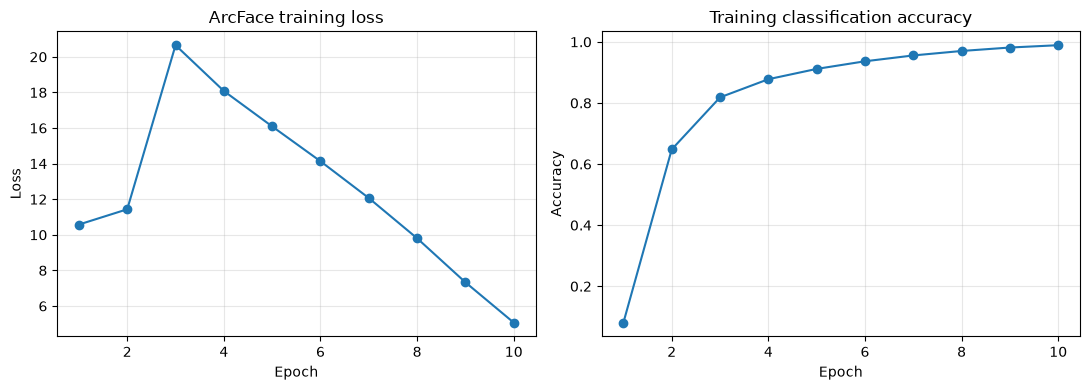

1753

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([row['epoch'] for row in history], [row['loss'] for row in history], marker='o')
axes[0].set(title='ArcFace training loss', xlabel='Epoch', ylabel='Loss')
axes[1].plot([row['epoch'] for row in history], [row['accuracy'] for row in history], marker='o')
axes[1].set(title='Training classification accuracy', xlabel='Epoch', ylabel='Accuracy')
for axis in axes:
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(WORK_DIR / 'training_curves.png', dpi=160)
plt.show()
(WORK_DIR / 'history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')

## 5.4 LFW 10 折验证

LFW deep-funneled 图像已完成对齐。先为所有配对涉及的图像提取一次特征，再逐折用其余九折选择余弦阈值。

In [9]:
checkpoint = torch.load(WORK_DIR / 'latest.pth', map_location=DEVICE)
model.load_state_dict(checkpoint['model'])
pairs = read_lfw_pairs(PAIRS_CSV, LFW_ROOT)
unique_paths = sorted({path for pair in pairs for path in pair[:2]})
missing = [path for path in unique_paths if not path.exists()]
assert not missing, f'LFW 缺少 {len(missing)} 张图片'
lfw_loader = DataLoader(
    ImagePathDataset(unique_paths, evaluation_transform()),
    batch_size=128, num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == 'cuda',
)
embeddings = extract_embeddings(model, lfw_loader, DEVICE)
results = evaluate_lfw(pairs, embeddings)
print(f"LFW Accuracy: {results['accuracy']:.4%} ± {results['std']:.4%}")
print('各折 Accuracy:', [round(value, 4) for value in results['fold_accuracies']])
target = CONFIG['lfw_target_accuracy']
print('目标状态:', f'已达到 {target:.1%}' if results['accuracy'] >= target else f"未达到 {target:.1%}（本次 {results['accuracy']:.1%}），受训练时间和子集规模限制")

LFW Accuracy: 80.2667% ± 2.2757%
各折 Accuracy: [0.8, 0.7817, 0.7967, 0.7867, 0.8117, 0.8217, 0.8467, 0.7617, 0.7983, 0.8217]
目标状态: 未达到 98.5%（本次 80.3%），受训练时间和子集规模限制


In [10]:
summary = {
    'lfw_accuracy': results['accuracy'],
    'lfw_std': results['std'],
    'fold_accuracies': results['fold_accuracies'],
    'fold_thresholds': results['fold_thresholds'],
}
(WORK_DIR / 'lfw_results.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary

{'lfw_accuracy': 0.8026666666666668,
 'lfw_std': 0.02275717225159771,
 'fold_accuracies': [0.8,
  0.7816666666666666,
  0.7966666666666666,
  0.7866666666666666,
  0.8116666666666666,
  0.8216666666666667,
  0.8466666666666667,
  0.7616666666666667,
  0.7983333333333333,
  0.8216666666666667],
 'fold_thresholds': [0.5800000000000001,
  0.5800000000000001,
  0.5800000000000001,
  0.5800000000000001,
  0.5800000000000001,
  0.583,
  0.5800000000000001,
  0.5800000000000001,
  0.5760000000000001,
  0.5800000000000001]}

## 实验结论

- 本实验使用 MS-Celeb-1M 的真实子集训练 ResNet50 + ArcFace，子集包含 1,000,000 张人脸图像和 12,299 个身份。单张 RTX 3080 完成 10 epochs 共耗时约 73.0 分钟，满足两小时训练预算。
- margin 预热结束后，训练 Loss 从第 3 轮的 20.6530 下降至第 10 轮的 5.0668，无 margin 分类 Accuracy 从 81.84% 上升至 98.91%，说明模型已充分拟合训练子集。
- LFW 标准 10 折验证 Accuracy 为 **80.2667% ± 2.2757%**，各折结果为 76.17%～84.67%。该结果低于 98.5% 目标 18.23 个百分点，因此不能认为本次模型达到预定识别精度。
- 训练集分类准确率较高而 LFW 验证准确率明显偏低，表明模型对训练身份的拟合强于对未见身份的泛化。主要限制包括仅使用部分 MS-Celeb-1M 身份、训练轮数受时间预算约束，以及训练图像与 LFW 图像之间的分布差异。训练曲线、检查点和 LFW 分折结果分别保存在 `training_curves.png`、`latest.pth` 和 `lfw_results.json` 中。

## 参考资料

1. He et al., *Deep Residual Learning for Image Recognition*, CVPR 2016.
2. Deng et al., *ArcFace: Additive Angular Margin Loss for Deep Face Recognition*, CVPR 2019.
3. Huang et al., *Labeled Faces in the Wild*, 2007.